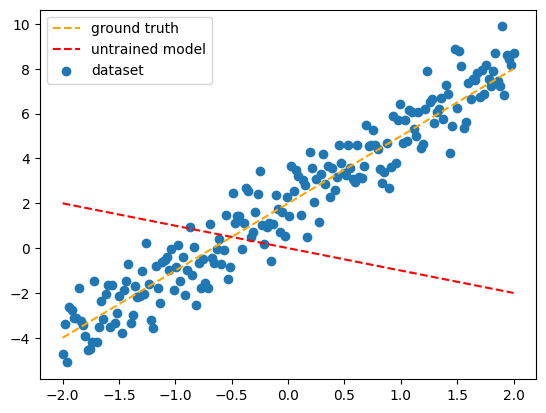

In [19]:
import tensorflow as tf
import matplotlib.pyplot as plt
import numpy as np

class Modello(tf.Module):
    def __init__(self, **kwargs):
        super().__init__(**kwargs)
        self._w = tf.Variable(-1.)
        self._b = tf.Variable(0.)

        self.weights = [self._w]
        self.biases = [self._b]
        self.losses = []

    def __call__(self, x):
        return self._w * x + self._b
    
    # Loss = RMS
    def loss(self, y_true, y_pred):
        return tf.reduce_mean(tf.square(y_true - y_pred))
    
    def get_losses(self):
        return self.losses
    
    # Implementa un ciclo di training: forward pass + backpropagation
    def train(self, y_true, x, learning_rate = .1):
        with tf.GradientTape() as t:
            current_loss = self.loss(y_true, self.__call__(x))

            dw, db = t.gradient(current_loss, [self._w, self._b])

            self._w.assign_sub(dw * learning_rate)
            self._b.assign_sub(db * learning_rate)

    # Implementa un loop di training per un numero specificato di epoche
    def training_loop(self, x, y_true, learning_rate = .1, epochs = 10):
        self.losses = []
        for epoch in range(epochs):
            self.train(y_true, x, learning_rate)

            current_loss = self.loss(y_true, self.__call__(x))

            self.weights.append(self._w)
            self.biases.append(self._b)
            self.losses.append(current_loss)

            print(f"\nEpoch {epoch}:\n\t Loss: {current_loss}")


# Ground Truth
def f(x):
    return 3. * x + 2.


model = Modello()

x = tf.linspace(-2,2, 200)
x = tf.cast(x, tf.float32)

y = f(x) + tf.random.normal(shape=x.shape)


y_untrained = model(x)

plt.plot(x, f(x),'--' ,label="ground truth", color="orange")
plt.plot(x, y_untrained,'--' ,label="untrained model", color="red")
plt.scatter(x, y, label="dataset")
plt.legend()

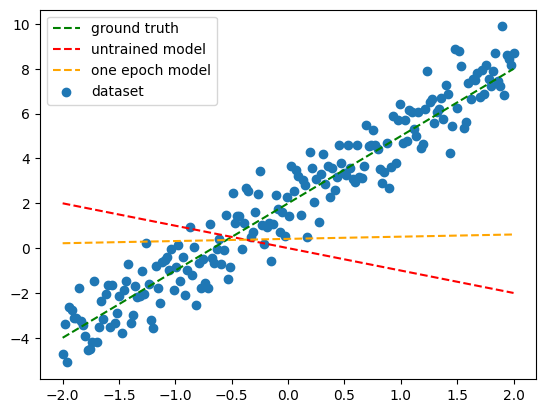

In [20]:
model.train(y,x)
y_first_train = model(x)

plt.plot(x, f(x),'--' ,label="ground truth", color="green")
plt.plot(x, y_untrained,'--' ,label="untrained model", color="red")
plt.plot(x, y_first_train,'--' ,label="one epoch model", color="orange")
plt.scatter(x, y, label="dataset")
plt.legend()


Epoch 0:
	 Loss: 9.089447021484375

Epoch 1:
	 Loss: 5.486759185791016

Epoch 2:
	 Loss: 3.496434211730957

Epoch 3:
	 Loss: 2.3910019397735596

Epoch 4:
	 Loss: 1.773412823677063

Epoch 5:
	 Loss: 1.4261431694030762

Epoch 6:
	 Loss: 1.2295085191726685

Epoch 7:
	 Loss: 1.1173386573791504

Epoch 8:
	 Loss: 1.0528510808944702

Epoch 9:
	 Loss: 1.015476942062378


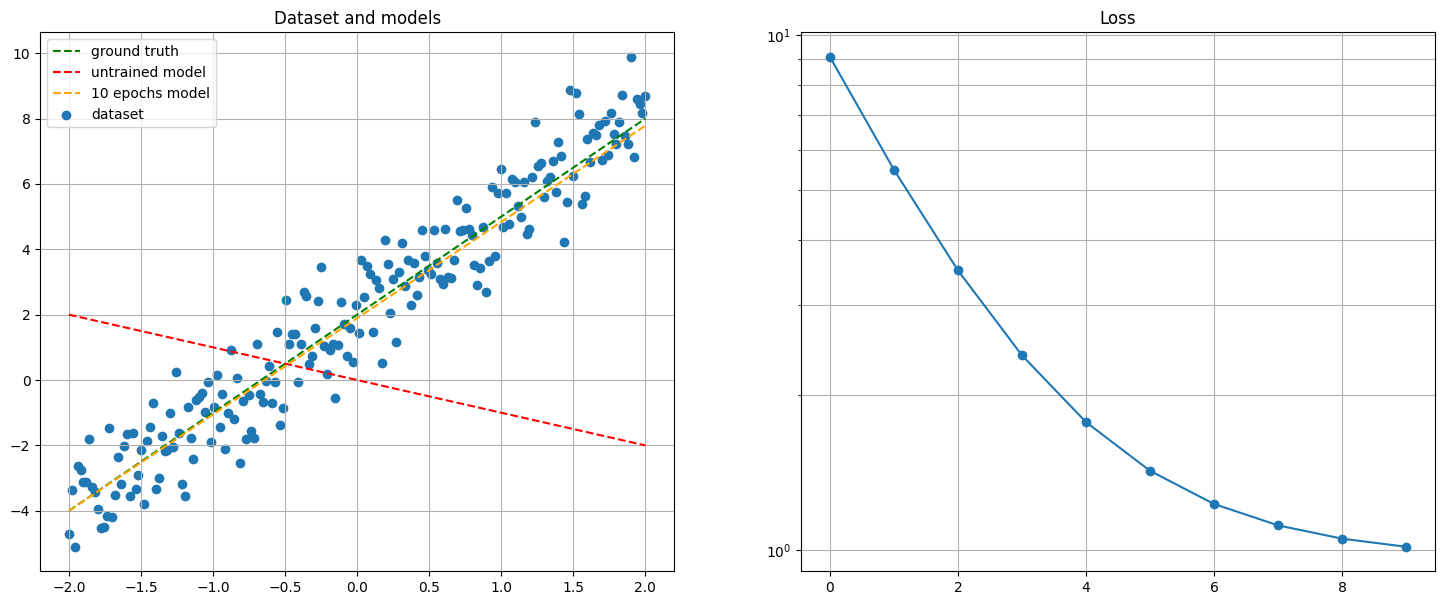

In [21]:
epochs = 10
model.training_loop(x,y, epochs=10)
y_trained = model(x)


fig = plt.figure(figsize=(18,7))
a = plt.subplot(1,2,1)
plt.grid(True, 'both')
plt.title('Dataset and models')
plt.plot(x, f(x),'--' ,label="ground truth", color="green")
plt.plot(x, y_untrained,'--' ,label="untrained model", color="red")
plt.plot(x, y_trained,'--' ,label="10 epochs model", color="orange")
plt.scatter(x, y, label="dataset")
plt.legend()

a = plt.subplot(1,2,2)
plt.semilogy()
plt.title('Loss')
plt.grid(True, 'both', 'both')
plt.plot(range(epochs), model.get_losses(), '-o')


## Implementation with keras API

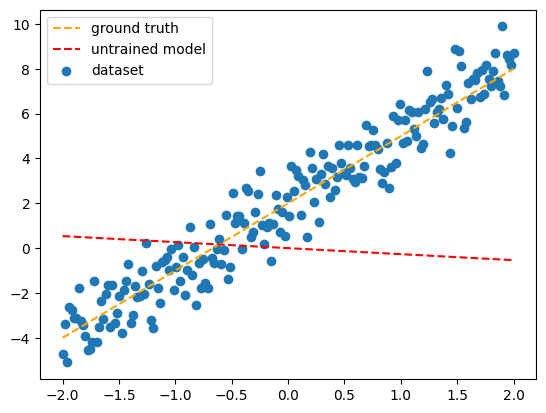

In [22]:
model2 = tf.keras.Sequential()

model2.add(tf.keras.layers.Input(shape=(1,)))
model2.add(tf.keras.layers.Dense(1))

y_untrained = model2(x)

plt.plot(x, f(x),'--' ,label="ground truth", color="orange")
plt.plot(x, y_untrained,'--' ,label="untrained model", color="red")
plt.scatter(x, y, label="dataset")
plt.legend()


In [23]:
model2.compile(optimizer=tf.keras.optimizers.SGD(learning_rate=.1), 
                    loss = tf.keras.losses.MeanSquaredError)

history = model2.fit(x, y, epochs=epochs, batch_size=len(x), verbose=0)

print(history.history['loss'])


[20.29850959777832, 11.739083290100098, 7.005988597869873, 4.374495983123779, 2.9026477336883545, 2.0740063190460205, 1.604183554649353, 1.335799217224121, 1.181278109550476, 1.0915905237197876]


/var/folders/g_/3dpvp_h12blfrzxnvvfj2q1m0000gn/T/ipykernel_2405/3693642576.py:15: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


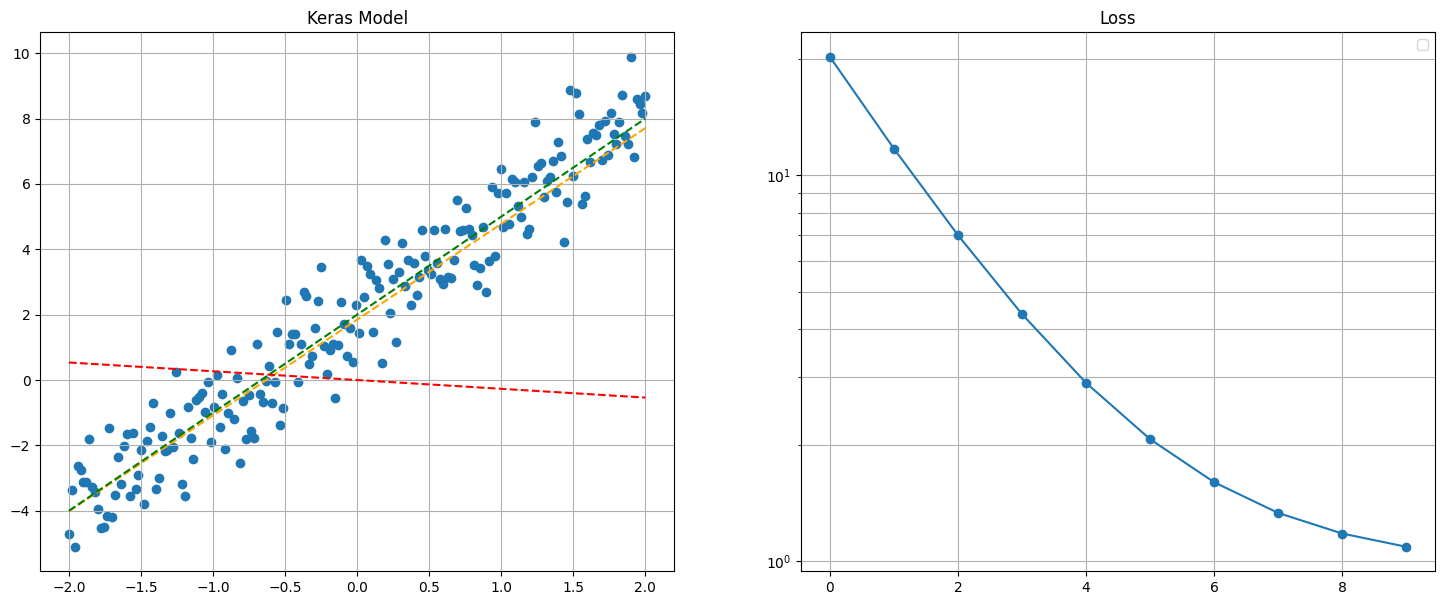

In [24]:
fig = plt.figure(figsize=(18,7))
a = plt.subplot(1,2,1)
plt.plot(x, model2(x), '--', label='Keras Model 10 epochs', color='orange')
plt.plot(x, f(x),'--' ,label="ground truth", color="green")
plt.plot(x, y_untrained,'--' ,label="untrained model", color="red")
plt.scatter(x, y, label="dataset")
plt.title('Keras Model')
plt.grid('both')

a = plt.subplot(1,2,2)
plt.semilogy()
plt.title('Loss')
plt.grid(True, 'both', 'both')
plt.plot(range(epochs), history.history['loss'], '-o')
plt.legend()
